# NIBLEs Tutorial Part 4: Imaging

We, at last, come to producing MR images with NIBLEs. Once again, we'll begin by importing the relevant tools:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import NIBLEs.experiment as NIBLEs
import NIBLEs.gradcal as gCal
import NIBLEs.fieldfunc as field
import NIBLEs.relaxfunc as relax

We'll begin with a simple 1D gradient echo. 

In order to perform a sucessful imaging experiment, we need to calibrate the amplitude of the frequency encoding gradients. To assist with this, NIBLEs contains a library named `./NIBLEs/simcode/gradcal.py`. This library contains a variety of functions for calculating gradient amplitude and duration depending on what parameters you wish to specify for your imaging gradients. All functions within this library require you to specify the field-of-view and the number of acquisition points (and/or phase encode steps) for your imaging experiment. 

For frequency encoding, `gradcal.py` contains functions that calculate the remaining gradient parameters based on either a set gradient duration (`freq_encode_amp_cal()`)or the desired total readout bandwidth (`freq_encode_dur_amp_cal()`). Please note that these functions assume a constant gradient amplitude.

Before we begin our experiment, let's define our imaging parameters. For the 1D experiment, let's use the square sample we created in Part 3. In the cell below, please define:
* Sample path and file
* Length of the field-of-view 
* Number of acquisition points 
* Either the duration or bandwidth of the readout gradient. 

Then, use these quantities and the functions in `gradcal.py` to calculate the remaining readout gradient paramters (Gradient amplitude and/or duration). Finally, use all of the above to calculate the amplitude and duration of your prepatory gradient. Please feel free to choose a set of parameters that are to your liking; if you're feeling uncreative please set the duration of the preparation gradient to 2 ms, and the duration of the readout gradient to 4 ms. Remember that you cannot set the number of acquired points higher than the resolution of the sample if you want to accurately image the sample!

Additionally, while we're defining our parameters let's define the flip angle and duration of our RF pulse. Please define a 1.28 ms pulse, with a flip angle of 60 degrees applied along the -x-axis.

In [2]:
# Your Work Here

sample_path = "/home/john/Documents/PhD/Code_and_Tools/Python/NIBLEs/samples"
sample_name = "NIBLEsTutorial_Square_12Vectors_64x64_10.0cm"


fov = 10e-2
n_points = 64
prep_dur = 2e-3
read_dur = 4e-3

rf_dur = 1.28e-3
flip_angle = 60
phi = 180

read_amp = gCal.freq_encode_amp_cal(duration= read_dur, fov = fov,
                                    n_points = n_points)

read_prep_amp = -read_amp*read_dur/(2*prep_dur)

Now, we can code our pulse sequence! Please create an instance of `Experiment` and load in our sample, as we did in Part 2, and apply an `rf_pulse` to excite magnetization. For this example, let's continue using a main field strength of 3.0T.

In [3]:
exp = NIBLEs.Experiment(b0 = [0, 0, 3])
exp.sequence_start(sample_name = sample_name, sample_path = sample_path)
exp.rf_pulse(duration = rf_dur, brf_func = field.rf_sinc,
             flip_angle = flip_angle, phi = phi)

Loading Sample...
Calculating b90 Amplitude...
Transverse Mag = 0.567132303831645 @ b90 = 1e-05 T
Transverse Mag = 0.9307227855156329 @ b90 = 2e-05 T
Transverse Mag = 0.9602701954267687 @ b90 = 3.0000000000000004e-05 T
Transverse Mag = 0.6451449581257792 @ b90 = 4e-05 T
Reducing Step Size....
Transverse Mag = 0.9499121604280741 @ b90 = 2.1000000000000002e-05 T
Transverse Mag = 0.9655861695892487 @ b90 = 2.2000000000000003e-05 T
Transverse Mag = 0.9776867889280026 @ b90 = 2.3000000000000003e-05 T
Transverse Mag = 0.9861692174806275 @ b90 = 2.4000000000000004e-05 T
Transverse Mag = 0.9910020411358694 @ b90 = 2.5000000000000005e-05 T
Transverse Mag = 0.9921673504144991 @ b90 = 2.6000000000000005e-05 T
Transverse Mag = 0.9896608056530997 @ b90 = 2.7000000000000006e-05 T
Reducing Step Size....
Transverse Mag = 0.9912837882832887 @ b90 = 2.5100000000000004e-05 T
Transverse Mag = 0.9915288386859514 @ b90 = 2.5200000000000003e-05 T
Transverse Mag = 0.9917371833085519 @ b90 = 2.5300000000000002

Next we need to apply our preparation gradient. To simulate a simple gradient, we need to use the `Experiment.Gradient` function.

`Experiment.Gradient` requires the following inputs:
* `duration` - Duration of the waveform (s)
* `brf_func` - A function to calculate the gradient waveform
* `grad_amp` - A 3-element list indicating the strength of the gradient along each axis. By default, `grad_amp = [0, 0, 0]`
* `rise_time` - Time taken for gradient to ramp up to maximum amplitude in T/m/s. By default, `rise_time = 0`
* `**kwargs` - Any additional keyword arguments required for gradient waveform definition. For futher details, please refer to the NIBLEs documentation.

For this example we will use an ideal constant gradient, which is defined by the function `fieldfunc.grad_ideal_square`. We have already specified (or calculated) everything else we need to define our prepatory gradient (rise_time is not used for an ideal constant gradient). Please call `Experiment.gradient` using the parameters you've already calculated. You are free to choose to image either along the x- or y- axes.

In [4]:
exp.gradient(duration = prep_dur, bgrad_func = field.grad_ideal_square,
             grad_amp = [read_prep_amp, 0, 0])

gradient: Amp = [-0.00375763  0.          0.        ] T, Dur = 0.002 s


In order to acquire signal while a gradient is being applied, we need to make use of `Experiment.freq_encode_grad`. This function requires the same inputs as `Experiment.gradient` above; the only additional parameter required is the number of acquisition points. As with `Experiment.acquisition`, `Experiment.freq_encode_grad` will automatically generate complex signal, saved in the variable `Experiment.readout`

Please call `Experiment.freq_encode_grad` below.

In [5]:
exp.freq_encode_grad(duration = read_dur, bgrad_func = field.grad_ideal_square,
                     grad_amp = [read_amp, 0, 0], n_points = n_points)

Readout grad: Amp = [0.00375763 0.         0.        ] T, Dur= 0.004 s
acquisition: n_points = 64


To turn this acquired data into an image, `Experiment` contains a function that performs  basic image generation tasks named `Experiment.image_processing`. This function performs a Fast Fourier Transform on the acquired data, with the option of applying a Hanning filter to reduce Gibb's ringing. `Experiment.image_processing` automatically reads k-space data from one of two variables: `Experiment.signal`, which we saw in part 2 of this tutorial; and `Experiment.noisy_signal`, which is where NIBLEs' noise genration functions stores noisy k-space data (we will discuss noise in more detail later).

`Experiment.image_processing` requires the following inputs:
* `n_dim` - Number of dimensions of input data, expressed as an integer. Only will perform analysis if `1` or `2` are given.
* `seq_name` - String naming the pulse sequence being simulated
* `sample_name` - String naming the sample file being used
* `save_path` - String naming path to output files
* `save_flag_csv` - Boolean variable indicating if signal and image data should be saved as `.csv` files. By default, `save_flag_csv = False`
* `save_flag_img` - Boolean variable indicating if signal and image data should be plotted and saved as `.png` files. By default, `save_flag_img = False`
* `hann_flag` - Boolean variable indicating if Hanning filtering should be applied. By default, `hann_flag = False`
* `grad_amp` - A 3-element list indicating the maximum strength of the gradients along each axis, to be used in calculating the Hanning filter.
* `noisy_signal` - Boolean variable indicating whether k-space data should be read from `Experiment.noisy_signal` instead of  `Experiment.signal`. By default, `noisy_signal = False`

`image_processing` will automatically name the output files using the given sample and sequence names.

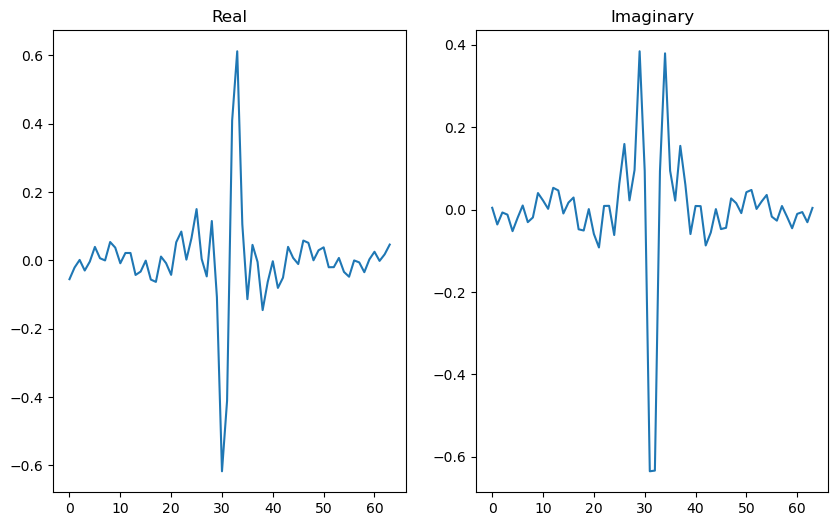

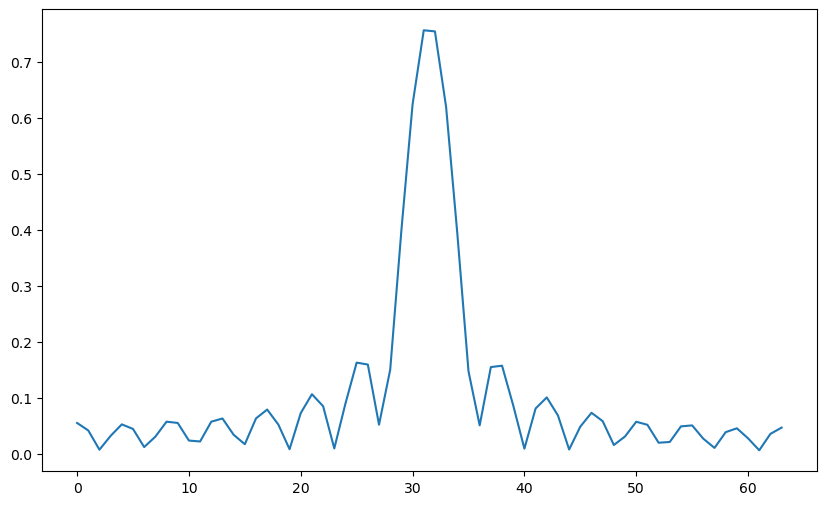

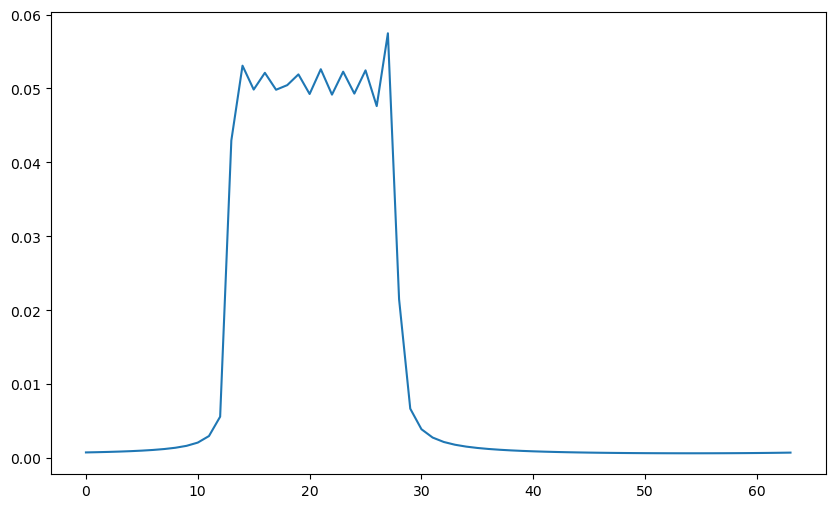

In [6]:
exp.signal = exp.readout
save_path = '/home/john/Documents/PhD/Code_and_Tools/Python/NIBLEs/'
seq_name = '1D-GRE_NIBLEsTutorial'

exp.save_acquisition(exp.signal, seq_name = seq_name,
                     sample_name = sample_name)
exp.image_processing(n_dim = 1, seq_name = seq_name, sample_name = sample_name,
                     save_path = save_path, save_flag_img = True)

Congratulations on simulating your first image! Let's move on to 2D imaging now by coding a basic 2D-GRE sequence. 

Before we get to the added wrinkles of 2D imaging, let's begin by establishing our defined quantities. In the cell below, please define or calculate:

* The file path for your sample folder
* The sample to be used
* A name for your pulse sequence (we recommend `2D-GRE_NIBLEsTutorial`)
* The relevant parameters for your RF pulse (duration, flip angle, phase)
* The relevant parameters for your gradients (fov, number of acquisition points, frequency encoding duration/ bandwidth, frequency encoding amplitude)

As we are performing 2D imaging, we recommend defining fovand acquisition point numbers as lists or arrays, where each element corresponds to one dimesions of your imaging volume.


In [7]:
# Your Work Here

sample_path = "/home/john/Documents/PhD/Code_and_Tools/Python/NIBLEs/samples/"
seq_name = '2D-GRE_NIBLEsTutorial'
sample_name = "NIBLEsTutorial_Square_12Vectors_64x64_10.0cm"

rf_dur = 1.28e-3
flip_angle = 90
phi = 0

fov= [10e-2, 10e-2]
n_points = [64, 64]
prep_dur = 2e-3
read_dur = 4e-3

read_amp = gCal.freq_encode_amp_cal(duration= read_dur, fov= fov[0],
                                    n_points = n_points[0])
read_prep_amp = -read_amp*read_dur/(2*prep_dur)

We have two final topics to discuss with 2D imaging. 

Firstly, we need to calculate our phase encoding gradients. As with the frequency encodiing gradients discussed above, NIBLEs includes a basic phase gradient calibration function in `gradcal.py` named `phase_encode_amp_cal` for Cartesian acquisitions. This function uses the same inputs as `freq_encode_amp_cal`, and returns two outputs: a NumPy array containing the amplitude of each phase encoding gradient needed for the acquisition, ordered from the center of k-space outwards; and a corresponding array of index values indicating which k-space line is encoded by each amplitude. 2D imaging is acheived by iterating over your sequence code with a different phase encode amplitude for each iteration.

Secondly, we need to introduce signal manipulation. In NIBLEs we have complete knowledge of our sample and its behaviour, and we can use this to speed simulation times in some circumstances. If at any point we need to wait for our sample to relax to equilibrium, we can avoid simulating that relaxation time by manually resetting the current state of magnetization of our sample to it's known equilibrium state. This can be easily accomplished with the method `Experiment.reset_magnetization`. This method requires no inputs; it automatically resets mangetization using information stored in the `Experiment` class.

Please calculate your phase encoding gradients in the cell below, then create an instance of `Experiment` and code a simple 2D-GRE sequence. Don't forget to define `Experiment.signal` (this time, as a 2D complex array), and be sure to iterate over each phase encode amplitude. As best practice, save `Experiment.signal` using `Experiment.save_acquisition` with every iteration. This will prevent data loss should a simulation be ended prematurely. Use `Experiment.reset_magnetization` to avoid having to simulate a full $tr$ between each excitation pulse.


In [8]:


phase_amp_steps, indeces = gCal.phase_encode_amp_cal(duration= prep_dur,
                                            n_points= n_points[1], fov= fov[1])

exp1 = NIBLEs.Experiment(b0 = [0, 0, 3])
exp1.sequence_start(sample_name = sample_name, sample_path = sample_path)

exp1.signal = np.zeros(n_points).astype(complex)

for i in range(n_points[1]):
    exp1.rf_pulse(duration = rf_dur, brf_func = field.rf_sinc,
                  flip_angle = flip_angle, phi = phi)
    exp1.gradient(duration = prep_dur, bgrad_func = field.grad_ideal_square,
                  grad_amp = [read_prep_amp, phase_amp_steps[i], 0])
    exp1.freq_encode_grad(duration = read_dur,
                          bgrad_func = field.grad_ideal_square,
                          grad_amp = [read_amp, 0, 0],
                          n_points = n_points[0])
    exp1.signal[indeces[i], :] = exp1.readout
    exp1.save_acquisition(exp1.signal, seq_name = seq_name,
                          sample_name = sample_name)
    exp1.reset_magnetization()



Loading Sample...
Calculating b90 Amplitude...
Transverse Mag = 0.5671323038316505 @ b90 = 1e-05 T
Transverse Mag = 0.9307227855156234 @ b90 = 2e-05 T
Transverse Mag = 0.9602701954267884 @ b90 = 3.0000000000000004e-05 T
Transverse Mag = 0.6451449581257813 @ b90 = 4e-05 T
Reducing Step Size....
Transverse Mag = 0.9499121604280604 @ b90 = 2.1000000000000002e-05 T
Transverse Mag = 0.9655861695892404 @ b90 = 2.2000000000000003e-05 T
Transverse Mag = 0.9776867889280079 @ b90 = 2.3000000000000003e-05 T
Transverse Mag = 0.9861692174806342 @ b90 = 2.4000000000000004e-05 T
Transverse Mag = 0.9910020411358582 @ b90 = 2.5000000000000005e-05 T
Transverse Mag = 0.9921673504144942 @ b90 = 2.6000000000000005e-05 T
Transverse Mag = 0.9896608056530909 @ b90 = 2.7000000000000006e-05 T
Reducing Step Size....
Transverse Mag = 0.9912837882832778 @ b90 = 2.5100000000000004e-05 T
Transverse Mag = 0.9915288386859368 @ b90 = 2.5200000000000003e-05 T
Transverse Mag = 0.9917371833085614 @ b90 = 2.530000000000000

Finally, please call `Experiment.image_processing` to see the results of your simulation.

<Figure size 1000x600 with 0 Axes>

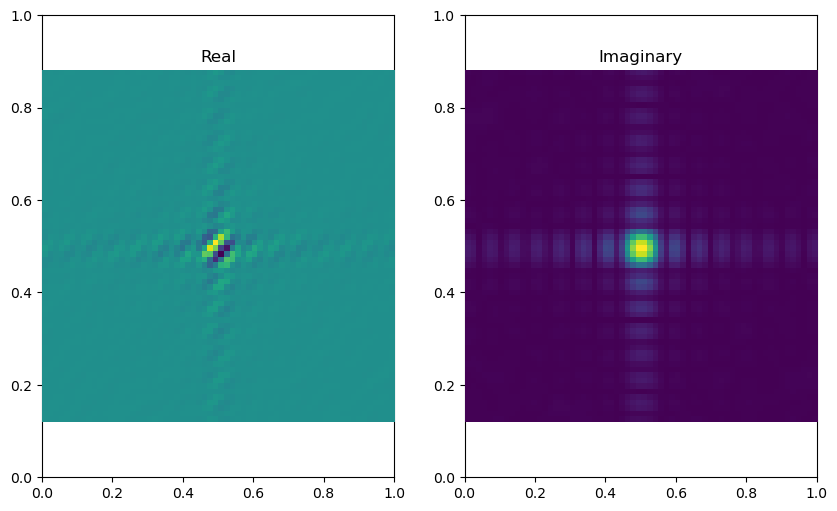

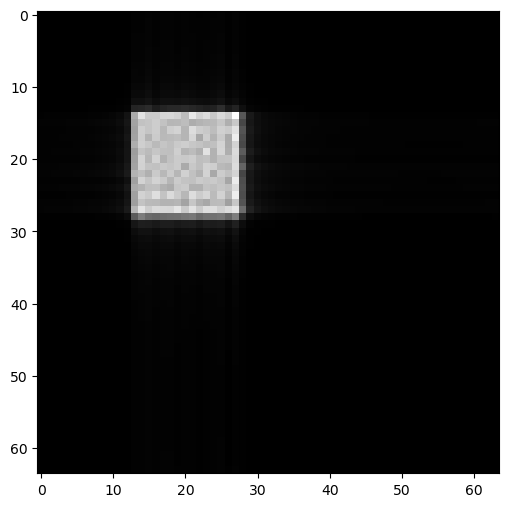

In [9]:
exp1.image_processing(n_dim = 2, seq_name = seq_name,
                      sample_name = sample_name, save_path = save_path,
                      save_flag_img = True)

If all went well, you should have a beautiful image of a square above!

Before we conclude this tutorial, the final subject we must touch on is spoiling gradients. 

As a final test, let's perform an imaging experiment on the brain sample we generated in Part 3. Using this sample, please code a 2D imaging sequence of your choosing below! We recommend a TSE or SPGR sequence.

In [2]:
# Your Work Here

sample_path = "/home/john/Documents/PhD/Code_and_Tools/Python/NIBLEs/samples/"
sample_name = "NIBLEsTutorial_Brain_12Vectors_64x64_30.0cm"
save_path = '/home/john/Documents/PhD/Code_and_Tools/Python/NIBLEs/'
seq_name = '2D-SPGR_NIBLEsTutorial'

rf_dur = 1.28e-3
flip_angle = 10
phi = 0

te = 4e-3
tr = 6e-3

fov= 30e-2
bandwidth = 50e3
n_points = [64, 64]
spoilAmp = 20e-3

read_amp, read_dur = gCal.freq_encode_dur_amp_cal(bandwidth = bandwidth,
                                            fov = fov, n_points = n_points[0])

prep_dur = (tr - read_dur - rf_dur)/3
read_prep_amp = -read_amp*read_dur/(2*prep_dur)

phase_amp_steps, indeces = gCal.phase_encode_amp_cal(duration = prep_dur,
                                            n_points = n_points[1], fov = fov)

dead_time = tr- rf_dur- 2*prep_dur- read_dur
recovery_time = (tr/(1- np.cos(np.deg2rad(flip_angle))))- prep_dur- rf_dur

exp2 = NIBLEs.Experiment(b0 = [0, 0, 3])
exp2.sequence_start(sample_name = sample_name,
                    sample_path = sample_path,
                    relax_func = relax.interpolation,
                    model_type = 'Dynamic')

exp2.signal = np.zeros(n_points).astype(complex)

exp2.rf_pulse(duration = rf_dur,
              brf_func = field.rf_sinc,
              flip_angle = 180,
              phi = 0)
exp2.deadtime(recovery_time)
exp2.gradient(prep_dur,
              field.grad_ideal_square,
              grad_amp = [-read_prep_amp, 0, spoilAmp])
exp2.null_transverse_mag()
for i in range(n_points[1]):
    exp2.rf_pulse(duration = rf_dur,
                  brf_func = field.rf_sinc,
                  flip_angle = flip_angle,
                  phi = phi)
    exp2.gradient(duration = prep_dur, bgrad_func = field.grad_ideal_square,
                  grad_amp = [read_prep_amp, phase_amp_steps[i], 0])
    exp2.freq_encode_grad(duration = read_dur,
                          bgrad_func = field.grad_ideal_square,
                          grad_amp = [read_amp, 0, 0],
                          n_points = n_points[0])
    exp2.signal[:, indeces[i]] = exp2.readout
    exp2.save_acquisition(exp2.signal,
                          seq_name = seq_name,
                          sample_name = sample_name)
    exp2.gradient(duration = prep_dur,
                  bgrad_func = field.grad_ideal_square,
                  grad_amp = [read_prep_amp, -phase_amp_steps[i], spoilAmp])
    exp2.null_transverse_mag()
    exp2.deadtime(duration = dead_time)



Loading Sample...
Calculating b90 Amplitude...
Transverse Mag = 0.4381579860063384 @ b90 = 1e-05 T
Transverse Mag = 0.7190931008403686 @ b90 = 2e-05 T
Transverse Mag = 0.7420004855469111 @ b90 = 3.0000000000000004e-05 T
Transverse Mag = 0.49866600987249327 @ b90 = 4e-05 T
Reducing Step Size....
Transverse Mag = 0.7339241259508203 @ b90 = 2.1000000000000002e-05 T
Transverse Mag = 0.7460397476111383 @ b90 = 2.2000000000000003e-05 T
Transverse Mag = 0.7553951438897463 @ b90 = 2.3000000000000003e-05 T
Transverse Mag = 0.7619557059073319 @ b90 = 2.4000000000000004e-05 T
Transverse Mag = 0.7656971658610455 @ b90 = 2.5000000000000005e-05 T
Transverse Mag = 0.7666056863840875 @ b90 = 2.6000000000000005e-05 T
Transverse Mag = 0.764677912293858 @ b90 = 2.7000000000000006e-05 T
Reducing Step Size....
Transverse Mag = 0.7659156377964512 @ b90 = 2.5100000000000004e-05 T
Transverse Mag = 0.7661057635716663 @ b90 = 2.5200000000000003e-05 T
Transverse Mag = 0.7662675362238148 @ b90 = 2.530000000000000

<Figure size 1000x600 with 0 Axes>

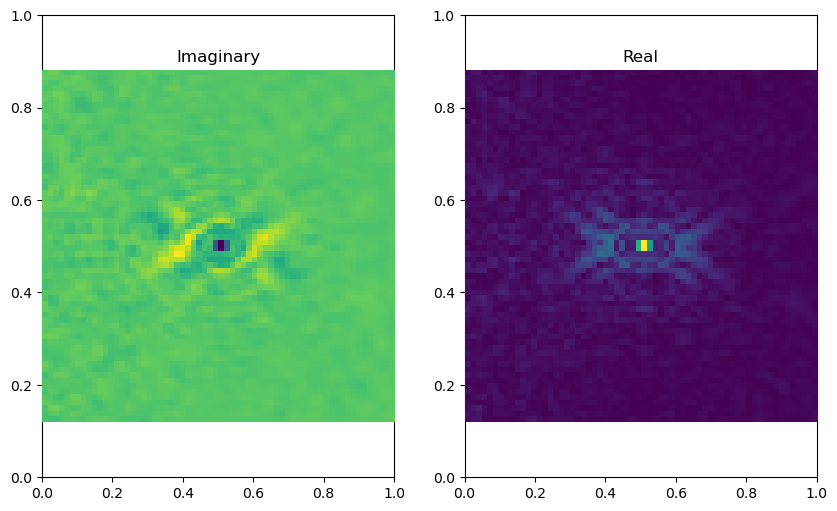

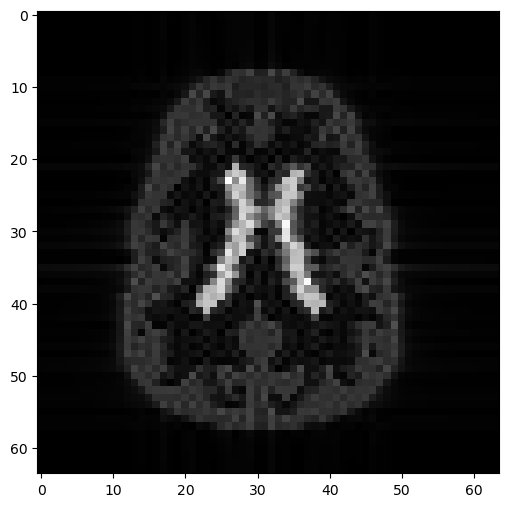

In [3]:
exp2.image_processing(n_dim = 2, seq_name = seq_name,
                      sample_name = sample_name, save_path = save_path,
                      save_flag_img = True)

#### Congratulations! You now know how to simulate a pulse sequence using NIBLEs! This is the end of our tutorial, we hope you find this tool useful for your own work!